In [5]:
import time
from datetime import datetime, timedelta
import os
import numpy as np
import pandas as pd
import requests


from web3 import Web3

from dotenv import load_dotenv
load_dotenv()

True

## Сбор данных

Блоки Ethereum из Google BigQuery:

```
SELECT timestamp, 
       number as height, 
       `hash`,
       size,
       gas_limit,
       gas_used,
       transaction_count,
       base_fee_per_gas
FROM `bigquery-public-data.crypto_ethereum.blocks` 
WHERE TIMESTAMP_TRUNC(timestamp, DAY) >= TIMESTAMP("2025-01-01") 
  and TIMESTAMP_TRUNC(timestamp, DAY) < TIMESTAMP("2026-02-16") 
```

In [3]:
df = pd.read_csv('data/eth_blocks_2025-01-01_2026-02-15.csv')
df

,timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas
0,2026-02-15 00:32:35 UTC,24458637,0x173fa6c45072b36b3b2489bf945c813f5eeb2fb7b7ce...,123436,59999886,17391909,108,35527943
1,2026-02-15 16:49:47 UTC,24463507,0xe0c7adb0bd468c81f23eb23627e60e5e373f1e1850da...,136110,59941351,24197479,272,46609559
2,2026-02-15 05:17:23 UTC,24460056,0xaf0bfcf9fecc2e7999c498184bbb9a36c50fcddd59a4...,206574,59941237,52959002,166,46207812
3,2026-02-15 14:31:35 UTC,24462819,0x8e9a8703ee7c65965eb2c4717ca74f9c48442f5d2542...,151227,59999886,42068893,263,33619778
4,2026-02-15 07:24:23 UTC,24460690,0xdca86811dbd9c17587a3b01bf72e16f1d633bc9d6ccb...,170208,59999886,46730062,481,48904977
...,...,...,...,...,...,...,...,...
2939758,2026-01-16 00:49:11 UTC,24243802,0xe03f9bf772619c82fc0a37bd64d25bbece1bbc3b9033...,236213,60000000,58358979,1156,40700653
2939759,2026-01-16 23:17:47 UTC,24250526,0xc3d889f810a1730f34473aaf4e6d463295d9180da2ee...,575739,60000000,59985849,178,29792259
2939760,2026-01-16 20:21:23 UTC,24249648,0x090cb4a592df450e965f775cbefd085620312cc003c4...,63704,60000000,12596083,154,50460437
2939761,2026-01-16 00:19:35 UTC,24243655,0xfc34e3be6633a3849bcc5e6155cf21ead59165682509...,83523,60000000,20000456,159,48073799


In [4]:
df.describe()

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas
count,2.939763e+06,2.939763e+06,2.939763e+06,2.939763e+06,2.939763e+06,2.939763e+06
mean,2.299577e+07,1.090783e+05,4.308254e+07,2.181120e+07,2.142717e+02,1.827983e+09
std,8.486366e+05,6.468409e+04,9.629040e+06,1.120064e+07,1.100360e+02,6.814647e+09
min,2.152589e+07,1.163000e+03,2.997070e+07,0.000000e+00,0.000000e+00,8.703865e+06
25%,2.226083e+07,7.005600e+04,3.596484e+07,1.432256e+07,1.490000e+02,1.561048e+08
50%,2.299577e+07,9.753000e+04,4.486800e+07,1.974043e+07,1.960000e+02,4.594324e+08
75%,2.373071e+07,1.336985e+05,4.504390e+07,2.730356e+07,2.560000e+02,1.250494e+09
max,2.446565e+07,1.956743e+06,6.011724e+07,6.005850e+07,2.753000e+03,8.255167e+11


In [6]:
print("=" * 60)
print("SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("COLUMNS & DTYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("MEMORY USAGE")
print("=" * 60)
print(df.memory_usage(deep=True).to_string())
print(f"\nTotal: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
print(missing_df[missing_df["count"] > 0] if missing_df["count"].sum() > 0 else "No missing values")

print("\n" + "=" * 60)
print("DUPLICATES")
print("=" * 60)
print(f"Duplicate rows: {df.duplicated().sum():,}")


print("\n" + "=" * 60)
print("UNIQUE VALUES PER COLUMN")
print("=" * 60)
for col in df.columns:
    n = df[col].nunique()
    print(f"  {col}: {n:,} unique")

SHAPE
Rows: 2,939,763  |  Columns: 8

COLUMNS & DTYPES
timestamp              str
height               int64
hash                   str
size                 int64
gas_limit            int64
gas_used             int64
transaction_count    int64
base_fee_per_gas     int64
dtype: object

MEMORY USAGE
Index                      132
timestamp            235181040
height                23518104
hash                 361590849
size                  23518104
gas_limit             23518104
gas_used              23518104
transaction_count     23518104
base_fee_per_gas      23518104

Total: 703.70 MB

MISSING VALUES
No missing values

DUPLICATES
Duplicate rows: 0

UNIQUE VALUES PER COLUMN
  timestamp: 2,939,763 unique
  height: 2,939,763 unique
  hash: 2,939,763 unique
  size: 304,168 unique
  gas_limit: 83,549 unique
  gas_used: 2,794,940 unique
  transaction_count: 1,853 unique
  base_fee_per_gas: 2,935,682 unique


### Цена ETH для обогащения датасета

In [92]:
# coingecko

API_KEY = os.getenv("COINGECKO_API_KEY")

url = "https://api.coingecko.com/api/v3/simple/price"

In [ ]:
params = {
    "ids": "ethereum",
    "vs_currencies": "usd"
}

headers = {
    "x-cg-demo-api-key": API_KEY
}

response = requests.get(url, params=params, headers=headers)

data = response.json()

eth_price = data["ethereum"]["usd"]

print(f"Current ETH price: ${eth_price}")

Current ETH price: $2075.69


In [ ]:
start_date = datetime(2025, 3, 6)
end_date = datetime(2026, 3, 5)

chunk_days = 90

rows = []

current_start = start_date

while current_start < end_date:

    current_end = min(current_start + timedelta(days=chunk_days), end_date)
    print(f"Fetching data from {current_start.date()} to {current_end.date()}...")
    
    params = {
        "vs_currency": "usd",
        "from": int(current_start.timestamp()),
        "to": int(current_end.timestamp())
    }

    response = requests.get(BASE_URL, params=params, headers=headers)
    data = response.json()

    prices = data["prices"]
    market_caps = data["market_caps"]
    volumes = data["total_volumes"]

    for i in range(len(prices)):
        timestamp = prices[i][0]

        rows.append({
            "timestamp": timestamp,
            "datetime": pd.to_datetime(timestamp, unit="ms"),
            "price": prices[i][1],
            "market_cap": market_caps[i][1],
            "volume": volumes[i][1]
        })

    print(f"Loaded {current_start.date()} → {current_end.date()}")

    current_start = current_end
    time.sleep(1)

df = pd.DataFrame(rows)

df = df.sort_values("datetime").reset_index(drop=True)

print(df.head())

Fetching data from 2025-03-06 to 2025-06-04...
Loaded 2025-03-06 → 2025-06-04
Fetching data from 2025-06-04 to 2025-09-02...
Loaded 2025-06-04 → 2025-09-02
Fetching data from 2025-09-02 to 2025-12-01...
Loaded 2025-09-02 → 2025-12-01
Fetching data from 2025-12-01 to 2026-03-01...
Loaded 2025-12-01 → 2026-03-01
Fetching data from 2026-03-01 to 2026-03-05...
Loaded 2026-03-01 → 2026-03-05
       timestamp                datetime        price    market_cap  \
0  1741208564423 2025-03-05 21:02:44.423  2230.584518  2.693445e+11   
1  1741212295383 2025-03-05 22:04:55.383  2236.766636  2.697674e+11   
2  1741215784773 2025-03-05 23:03:04.773  2239.435736  2.699957e+11   
3  1741219748187 2025-03-06 00:09:08.187  2244.935432  2.706242e+11   
4  1741223086191 2025-03-06 01:04:46.191  2239.385254  2.699733e+11   

         volume  
0  2.335307e+10  
1  2.253690e+10  
2  2.218404e+10  
3  2.222023e+10  
4  2.234494e+10  


In [17]:
df

,timestamp,datetime,price,market_cap,volume
0,1741208564423,2025-03-05 21:02:44.423,2230.584518,2.693445e+11,2.335307e+10
1,1741212295383,2025-03-05 22:04:55.383,2236.766636,2.697674e+11,2.253690e+10
2,1741215784773,2025-03-05 23:03:04.773,2239.435736,2.699957e+11,2.218404e+10
3,1741219748187,2025-03-06 00:09:08.187,2244.935432,2.706242e+11,2.222023e+10
4,1741223086191,2025-03-06 01:04:46.191,2239.385254,2.699733e+11,2.234494e+10
...,...,...,...,...,...
8731,1772640207826,2026-03-04 16:03:27.826,2150.392505,2.588748e+11,3.143937e+10
8732,1772643799382,2026-03-04 17:03:19.382,2143.077149,2.586854e+11,3.120427e+10
8733,1772647410540,2026-03-04 18:03:30.540,2147.037185,2.592250e+11,3.166291e+10
8734,1772650975057,2026-03-04 19:02:55.057,2162.208620,2.609615e+11,3.140737e+10


In [ ]:
BASE_URL = "https://data-api.coindesk.com/index/cc/v1/historical/minutes"

headers = {
    "Authorization": f"Apikey {API_KEY}"
}

market = "cadli"
instrument = "ETH-USD"

start_date = datetime(2025, 1, 1)
end_date = datetime(2026, 2, 17)

to_ts = int(end_date.timestamp())

limit = 2000

rows = []

while True:

    params = {
        "market": market,
        "instrument": instrument,
        "limit": limit,
        "to_ts": to_ts,
        "groups": "OHLC,VOLUME",
        "aggregate": 1
    }

    r = requests.get(BASE_URL, params=params, headers=headers)
    data = r.json()

    batch = data["Data"]

    if not batch:
        break

    rows.extend(batch)

    oldest_ts = batch[0]["TIMESTAMP"]

    print("Downloaded until:", datetime.fromtimestamp(oldest_ts))

    if oldest_ts <= int(start_date.timestamp()):
        break
    to_ts = oldest_ts - 60

    time.sleep(1)

Downloaded until: 2025-01-25 12:08:00
Downloaded until: 2025-01-24 02:48:00
Downloaded until: 2025-01-22 17:28:00
Downloaded until: 2025-01-21 08:08:00
Downloaded until: 2025-01-19 22:48:00
Downloaded until: 2025-01-18 13:28:00
Downloaded until: 2025-01-17 04:08:00
Downloaded until: 2025-01-15 18:48:00
Downloaded until: 2025-01-14 09:28:00
Downloaded until: 2025-01-13 00:08:00
Downloaded until: 2025-01-11 14:48:00
Downloaded until: 2025-01-10 05:28:00
Downloaded until: 2025-01-08 20:08:00
Downloaded until: 2025-01-07 10:48:00
Downloaded until: 2025-01-06 01:28:00
Downloaded until: 2025-01-04 16:08:00
Downloaded until: 2025-01-03 06:48:00
Downloaded until: 2025-01-01 21:28:00
Downloaded until: 2024-12-31 12:08:00
(37288, 15)
          UNIT   TIMESTAMP         open         high          low  \
592892  MINUTE  1735689600  3332.507632  3332.575058  3331.424175   
592893  MINUTE  1735689660  3332.575058  3333.252526  3332.369019   
592894  MINUTE  1735689720  3333.237763  3336.691150  3333.

In [87]:
df = pd.DataFrame(rows)
df["datetime"] = pd.to_datetime(df["TIMESTAMP"], unit="s")
df = df.sort_values("datetime")

df = df.rename(columns={
    "OPEN": "open",
    "HIGH": "high",
    "LOW": "low",
    "CLOSE": "close",
    "VOLUME": "volume"
})

df = df.drop_duplicates(subset=["TIMESTAMP"])
df

,UNIT,TIMESTAMP,open,high,low,close,volume,QUOTE_VOLUME,VOLUME_TOP_TIER,QUOTE_VOLUME_TOP_TIER,VOLUME_DIRECT,QUOTE_VOLUME_DIRECT,VOLUME_TOP_TIER_DIRECT,QUOTE_VOLUME_TOP_TIER_DIRECT,datetime
592000,MINUTE,1735636080,3378.569323,3380.485797,3378.217773,3380.465130,1767.621519,5.974709e+06,969.995245,3.278723e+06,88.282421,298298.946808,87.683491,296273.130839,2024-12-31 09:08:00
592001,MINUTE,1735636140,3380.465130,3382.087644,3379.523548,3381.908966,2500.374313,8.453734e+06,1622.858775,5.487008e+06,133.230708,450299.577347,132.825178,448927.966293,2024-12-31 09:09:00
592002,MINUTE,1735636200,3381.908966,3383.238625,3381.428658,3382.847440,2221.012152,7.513716e+06,1247.153641,4.219135e+06,188.263742,636652.513877,184.458903,623698.905942,2024-12-31 09:10:00
592003,MINUTE,1735636260,3382.847440,3383.516298,3382.149028,3382.240800,1515.060300,5.125635e+06,867.835997,2.936108e+06,85.229725,288205.770504,85.036495,287551.856548,2024-12-31 09:11:00
592004,MINUTE,1735636320,3382.240800,3383.575566,3381.438189,3381.591191,1391.147431,4.706566e+06,819.917387,2.773771e+06,78.714229,266118.741873,78.559561,265595.298606,2024-12-31 09:12:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,MINUTE,1771275360,1993.592348,1993.592436,1991.998667,1992.059820,2449.901777,4.879452e+06,1042.716522,2.076631e+06,169.015468,336451.804526,162.860668,324202.884306,2026-02-16 20:56:00
1996,MINUTE,1771275420,1992.059820,1993.146110,1991.808684,1992.881738,2614.963938,5.208310e+06,1282.120863,2.553640e+06,188.397666,375039.166557,187.591856,373435.571706,2026-02-16 20:57:00
1997,MINUTE,1771275480,1992.881738,1993.668483,1992.616035,1993.666354,2378.978058,4.741151e+06,1151.227796,2.294991e+06,157.786077,314198.056788,157.553098,313734.635499,2026-02-16 20:58:00
1998,MINUTE,1771275540,1993.666354,1994.365204,1993.646374,1993.967930,3014.687517,6.009953e+06,1534.545144,3.059086e+06,222.362850,443097.765103,218.906048,436208.518704,2026-02-16 20:59:00


In [88]:
df['datetime'].min(), df['datetime'].max()

(Timestamp('2024-12-31 09:08:00'), Timestamp('2026-02-16 21:00:00'))

In [89]:
df.to_csv("data/eth_minutes_2025_2026.csv", index=False)

In [ ]:
df = df.sort_values("datetime").reset_index(drop=True)

# вычисляем разницу между соседними часами
df["diff_minutes"] = df["datetime"].diff().dt.total_seconds() / 60

# проверяем, есть ли пропуски
missing_hours = df[df["diff_minutes"] != 1]

if missing_hours.empty:
    print("Все часы на месте! Пропусков нет.")
else:
    print("Есть пропуски часов:")
    print(missing_hours[["datetime", "diff_minutes"]])

Есть пропуски часов:
             datetime  diff_minutes
0 2024-12-31 09:08:00           NaN


### Обогащение датасета с блоками ценой ETH

In [14]:
blocks = pd.read_csv("data/eth_blocks_2025-01-01_2026-02-15.csv")
blocks

,timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas
0,2026-02-15 00:32:35 UTC,24458637,0x173fa6c45072b36b3b2489bf945c813f5eeb2fb7b7ce...,123436,59999886,17391909,108,35527943
1,2026-02-15 16:49:47 UTC,24463507,0xe0c7adb0bd468c81f23eb23627e60e5e373f1e1850da...,136110,59941351,24197479,272,46609559
2,2026-02-15 05:17:23 UTC,24460056,0xaf0bfcf9fecc2e7999c498184bbb9a36c50fcddd59a4...,206574,59941237,52959002,166,46207812
3,2026-02-15 14:31:35 UTC,24462819,0x8e9a8703ee7c65965eb2c4717ca74f9c48442f5d2542...,151227,59999886,42068893,263,33619778
4,2026-02-15 07:24:23 UTC,24460690,0xdca86811dbd9c17587a3b01bf72e16f1d633bc9d6ccb...,170208,59999886,46730062,481,48904977
...,...,...,...,...,...,...,...,...
2939758,2026-01-16 00:49:11 UTC,24243802,0xe03f9bf772619c82fc0a37bd64d25bbece1bbc3b9033...,236213,60000000,58358979,1156,40700653
2939759,2026-01-16 23:17:47 UTC,24250526,0xc3d889f810a1730f34473aaf4e6d463295d9180da2ee...,575739,60000000,59985849,178,29792259
2939760,2026-01-16 20:21:23 UTC,24249648,0x090cb4a592df450e965f775cbefd085620312cc003c4...,63704,60000000,12596083,154,50460437
2939761,2026-01-16 00:19:35 UTC,24243655,0xfc34e3be6633a3849bcc5e6155cf21ead59165682509...,83523,60000000,20000456,159,48073799


In [15]:
eth_prices = pd.read_csv("data/eth_minutes_2025_2026.csv")
eth_prices

,UNIT,TIMESTAMP,open,high,low,close,volume,QUOTE_VOLUME,VOLUME_TOP_TIER,QUOTE_VOLUME_TOP_TIER,VOLUME_DIRECT,QUOTE_VOLUME_DIRECT,VOLUME_TOP_TIER_DIRECT,QUOTE_VOLUME_TOP_TIER_DIRECT,datetime
0,MINUTE,1735636080,3378.569323,3380.485797,3378.217773,3380.465130,1767.621519,5.974709e+06,969.995245,3.278723e+06,88.282421,298298.946808,87.683491,296273.130839,2024-12-31 09:08:00
1,MINUTE,1735636140,3380.465130,3382.087644,3379.523548,3381.908966,2500.374313,8.453734e+06,1622.858775,5.487008e+06,133.230708,450299.577347,132.825178,448927.966293,2024-12-31 09:09:00
2,MINUTE,1735636200,3381.908966,3383.238625,3381.428658,3382.847440,2221.012152,7.513716e+06,1247.153641,4.219135e+06,188.263742,636652.513877,184.458903,623698.905942,2024-12-31 09:10:00
3,MINUTE,1735636260,3382.847440,3383.516298,3382.149028,3382.240800,1515.060300,5.125635e+06,867.835997,2.936108e+06,85.229725,288205.770504,85.036495,287551.856548,2024-12-31 09:11:00
4,MINUTE,1735636320,3382.240800,3383.575566,3381.438189,3381.591191,1391.147431,4.706566e+06,819.917387,2.773771e+06,78.714229,266118.741873,78.559561,265595.298606,2024-12-31 09:12:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593988,MINUTE,1771275360,1993.592348,1993.592436,1991.998667,1992.059820,2449.901777,4.879452e+06,1042.716522,2.076631e+06,169.015468,336451.804526,162.860668,324202.884306,2026-02-16 20:56:00
593989,MINUTE,1771275420,1992.059820,1993.146110,1991.808684,1992.881738,2614.963938,5.208310e+06,1282.120863,2.553640e+06,188.397666,375039.166557,187.591856,373435.571706,2026-02-16 20:57:00
593990,MINUTE,1771275480,1992.881738,1993.668483,1992.616035,1993.666354,2378.978058,4.741151e+06,1151.227796,2.294991e+06,157.786077,314198.056788,157.553098,313734.635499,2026-02-16 20:58:00
593991,MINUTE,1771275540,1993.666354,1994.365204,1993.646374,1993.967930,3014.687517,6.009953e+06,1534.545144,3.059086e+06,222.362850,443097.765103,218.906048,436208.518704,2026-02-16 20:59:00


In [7]:
blocks.columns

Index(['timestamp', 'height', 'hash', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas'],
      dtype='str')

In [8]:
eth_prices.columns

Index(['UNIT', 'TIMESTAMP', 'open', 'high', 'low', 'close', 'volume',
       'QUOTE_VOLUME', 'VOLUME_TOP_TIER', 'QUOTE_VOLUME_TOP_TIER',
       'VOLUME_DIRECT', 'QUOTE_VOLUME_DIRECT', 'VOLUME_TOP_TIER_DIRECT',
       'QUOTE_VOLUME_TOP_TIER_DIRECT', 'datetime'],
      dtype='str')

In [ ]:
blocks['timestamp'] = pd.to_datetime(blocks['timestamp']).dt.tz_localize(None) # убираем timezone, чтобы не было проблем при объединении с ценами
eth_prices['datetime'] = pd.to_datetime(eth_prices['datetime']).dt.tz_localize(None)

In [18]:
blocks = blocks.sort_values('timestamp')
eth_prices = eth_prices.sort_values('datetime')

In [19]:
blocks_with_price = pd.merge_asof(
    blocks,
    eth_prices[['datetime', 'close']],
    left_on='timestamp',
    right_on='datetime',
    direction='backward' # чтобы избежать утечки будущего, всегда берем последнее известное значение цены
)

In [21]:
blocks_with_price.rename(columns={"close": "last_eth_price"}, inplace=True)

In [22]:
blocks_with_price.to_csv("data/blocks_with_price.csv", index=False)

In [24]:
blocks_with_price['last_eth_price'].isna().sum()

np.int64(0)

In [25]:
blocks_with_price

,timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,datetime,last_eth_price
0,2025-01-01 00:00:11,21525891,0x9512042c5c38145528389a91bd3d63193a1f48fb45d6...,97516,30000000,21883295,237,4169577181,2025-01-01 00:00:00,3332.575058
1,2025-01-01 00:00:23,21525892,0xdcb0914048de01deb90369935a391543aa38bd52155e...,104452,30029295,16025949,157,4408747429,2025-01-01 00:00:00,3332.575058
2,2025-01-01 00:00:35,21525893,0x17730ebffbab277d16c977e7d9ee319a4a84de0c1de8...,68718,30058619,15130746,161,4445865976,2025-01-01 00:00:00,3332.575058
3,2025-01-01 00:00:47,21525894,0x11a3524cfdb9ecf005c4ecf42ed98d1408519637fbeb...,74212,30029266,12779127,132,4449616774,2025-01-01 00:00:00,3332.575058
4,2025-01-01 00:00:59,21525895,0xae95734855fe73b0bdd920c4175fe749bb1df2b900e7...,98909,30058590,19670440,258,4366804685,2025-01-01 00:00:00,3332.575058
...,...,...,...,...,...,...,...,...,...,...
2939758,2026-02-15 23:59:11,24465649,0x5d02d188587d79425389960725bcf0c5146eb19df197...,102527,60000000,9939523,114,32174539,2026-02-15 23:59:00,1967.686511
2939759,2026-02-15 23:59:23,24465650,0x2234f11fe7250ecbc6c8a1b93bbb785427539f219b88...,49520,60000000,58483432,86,29485220,2026-02-15 23:59:00,1967.686511
2939760,2026-02-15 23:59:35,24465651,0x8913e1be6c98117d0c89c861a18d2d9450a4ad3d2fdf...,164337,60000000,38840910,356,32984554,2026-02-15 23:59:00,1967.686511
2939761,2026-02-15 23:59:47,24465652,0x54b473645250906f4dc3476ca1d4ca4f2b0e1d0e2157...,263005,60000000,34392991,366,34199610,2026-02-15 23:59:00,1967.686511


In [26]:
blocks_with_price.columns

Index(['timestamp', 'height', 'hash', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'datetime', 'last_eth_price'],
      dtype='str')

In [27]:
blocks_with_price.drop(columns=['datetime'], inplace=True)

# Feature engineering

Cоздадим несколько горизонтов прогнозирования.
В Ethereum блок  = 12 сек.

| горизонт   | блоков |
| ---------- | ------ |
| next block | 1      |
| 10 минут   | ~50    |
| 1 час      | ~300   |
| 1 день     | ~7200  |
| 1 неделя   | ~50400 |


In [32]:
df = blocks_with_price.copy()

df["target_next_block"] = df["base_fee_per_gas"].shift(-1)
df["target_10m"] = df["base_fee_per_gas"].shift(-int(60/12*10))
df["target_1h"] = df["base_fee_per_gas"].shift(-int(60/12*60))
df["target_1d"] = df["base_fee_per_gas"].shift(-int(60/12*60*24))
df["target_1w"] = df["base_fee_per_gas"].shift(-int(60/12*60*24*7))

Основные сетевые признаки (network state)
Base fee напрямую зависит от заполненности блока (EIP-1559). Base fee увеличивается если: gas_used > gas_limit / 2

In [33]:
df["block_utilization"] = df["gas_used"] / df["gas_limit"]

In [34]:
# давление на base fee.
df["gas_pressure"] = df["gas_used"] - df["gas_limit"] / 2

transactions density - proxy для типа транзакций (DeFi / swaps / NFT).

In [35]:
df["tx_per_gas"] = df["transaction_count"] / df["gas_used"]

#### Лаги

лаги base fee (gas fees имеют сильную автокорреляцию.)

In [36]:
lags = [1,2,3,5,10,20,50,100,300]

for lag in lags:
    df[f"base_fee_lag_{lag}"] = df["base_fee_per_gas"].shift(lag)

лаги utilization (сеть имеет инерцию загрузки)

In [37]:
for lag in [1,2,3,5,10,20]:
    df[f"utilization_lag_{lag}"] = df["block_utilization"].shift(lag)

#### Rolling признаки (тренды)

агрегаты на окнах:
1. rolling mean - покажет тренд комиссии
2. volatility - всплески комиссий часто происходят после роста волатильности
3. rolling utilization - отражает нагрузку сети

In [38]:
windows = [5, 20, 50, 300]

for w in windows:
    df[f"base_fee_ma_{w}"] = df["base_fee_per_gas"].rolling(w).mean()

In [39]:
for w in [20, 50, 300]:
    df[f"base_fee_vol_{w}"] = df["base_fee_per_gas"].rolling(w).std()

In [40]:
for w in [5, 20, 50]:
    df[f"utilization_ma_{w}"] = df["block_utilization"].rolling(w).mean()

#### ETH price признаки
Gas usage коррелирует с активностью рынка.

price returns - сильные движения цены → рост DeFi активности.

In [41]:
df["eth_return_1m"] = df["last_eth_price"].pct_change(5)
df["eth_return_10m"] = df["last_eth_price"].pct_change(50)
df["eth_return_1h"] = df["last_eth_price"].pct_change(300)

price volatility - волатильность → больше трейдинга → больше gas.

In [42]:
df["eth_volatility_1h"] = df["last_eth_price"].rolling(300).std()

#### Time features

В Ethereum активность может зависеть от времени суток

In [44]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

И сделаем cyclical encoding - сети имеют суточные паттерны.

In [45]:
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

In [62]:
df["minute"] = df["block_timestamp"].dt.minute
df["minute_sin"] = np.sin(2*np.pi*df["minute"]/60)
df["minute_cos"] = np.cos(2*np.pi*df["minute"]/60)

In [63]:
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

In [64]:
df.drop(columns=['minute'], inplace=True)

#### Momentum признаки

Всплески могут иметь momentum

In [46]:
df["base_fee_change_1"] = df["base_fee_per_gas"].pct_change()
df["base_fee_change_10"] = df["base_fee_per_gas"].pct_change(10)
df["base_fee_change_50"] = df["base_fee_per_gas"].pct_change(50)

#### Block growth features

sudden network demand.

In [47]:
df["gas_used_change"] = df["gas_used"].pct_change()
df["tx_change"] = df["transaction_count"].pct_change()

Итоговый датасет содержит примерно такие категории признаков:

- network metrics
- lag features
- rolling statistics
- price signals
- temporal features

In [48]:
df

,timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,target_next_block,...,eth_volatility_1h,hour,day_of_week,hour_sin,hour_cos,base_fee_change_1,base_fee_change_10,base_fee_change_50,gas_used_change,tx_change
0,2025-01-01 00:00:11,21525891,0x9512042c5c38145528389a91bd3d63193a1f48fb45d6...,97516,30000000,21883295,237,4169577181,3332.575058,4.408747e+09,...,NaN,0,2,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 00:00:23,21525892,0xdcb0914048de01deb90369935a391543aa38bd52155e...,104452,30029295,16025949,157,4408747429,3332.575058,4.445866e+09,...,NaN,0,2,0.000000,1.000000,0.057361,NaN,NaN,-0.267663,-0.337553
2,2025-01-01 00:00:35,21525893,0x17730ebffbab277d16c977e7d9ee319a4a84de0c1de8...,68718,30058619,15130746,161,4445865976,3332.575058,4.449617e+09,...,NaN,0,2,0.000000,1.000000,0.008419,NaN,NaN,-0.055860,0.025478
3,2025-01-01 00:00:47,21525894,0x11a3524cfdb9ecf005c4ecf42ed98d1408519637fbeb...,74212,30029266,12779127,132,4449616774,3332.575058,4.366805e+09,...,NaN,0,2,0.000000,1.000000,0.000844,NaN,NaN,-0.155420,-0.180124
4,2025-01-01 00:00:59,21525895,0xae95734855fe73b0bdd920c4175fe749bb1df2b900e7...,98909,30058590,19670440,258,4366804685,3332.575058,4.535367e+09,...,NaN,0,2,0.000000,1.000000,-0.018611,NaN,NaN,0.539263,0.954545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2939758,2026-02-15 23:59:11,24465649,0x5d02d188587d79425389960725bcf0c5146eb19df197...,102527,60000000,9939523,114,32174539,1967.686511,2.948522e+07,...,5.880528,23,6,-0.258819,0.965926,-0.058263,-0.009692,0.041056,-0.379433,-0.337209
2939759,2026-02-15 23:59:23,24465650,0x2234f11fe7250ecbc6c8a1b93bbb785427539f219b88...,49520,60000000,58483432,86,29485220,1967.686511,3.298455e+07,...,5.861143,23,6,-0.258819,0.965926,-0.083585,-0.182514,-0.151916,4.883927,-0.245614
2939760,2026-02-15 23:59:35,24465651,0x8913e1be6c98117d0c89c861a18d2d9450a4ad3d2fdf...,164337,60000000,38840910,356,32984554,1967.686511,3.419961e+07,...,5.841669,23,6,-0.258819,0.965926,0.118681,-0.015336,-0.002179,-0.335865,3.139535
2939761,2026-02-15 23:59:47,24465652,0x54b473645250906f4dc3476ca1d4ca4f2b0e1d0e2157...,263005,60000000,34392991,366,34199610,1967.686511,3.482560e+07,...,5.822104,23,6,-0.258819,0.965926,0.036837,0.056089,-0.018247,-0.114516,0.028090


In [49]:
df.columns

Index(['timestamp', 'height', 'hash', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'last_eth_price',
       'target_next_block', 'target_10m', 'target_1h', 'target_1d',
       'target_1w', 'block_utilization', 'gas_pressure', 'tx_per_gas',
       'base_fee_lag_1', 'base_fee_lag_2', 'base_fee_lag_3', 'base_fee_lag_5',
       'base_fee_lag_10', 'base_fee_lag_20', 'base_fee_lag_50',
       'base_fee_lag_100', 'base_fee_lag_300', 'utilization_lag_1',
       'utilization_lag_2', 'utilization_lag_3', 'utilization_lag_5',
       'utilization_lag_10', 'utilization_lag_20', 'base_fee_ma_5',
       'base_fee_ma_20', 'base_fee_ma_50', 'base_fee_ma_300',
       'base_fee_vol_20', 'base_fee_vol_50', 'base_fee_vol_300',
       'utilization_ma_5', 'utilization_ma_20', 'utilization_ma_50',
       'eth_return_1m', 'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h',
       'hour', 'day_of_week', 'hour_sin', 'hour_cos', 'base_fee_change_1',
       'base_fee_change_

In [50]:
df.rename(columns={"timestamp": "block_timestamp"}, inplace=True)

In [ ]:
df.to_csv("data/blocks_with_features.csv", index=False)

In [65]:
df.to_parquet("data/blocks_with_features.parquet.gzip", compression="gzip")

In [66]:
print(f'Итоговой датасет содержит {len(df.columns)} колонок и {len(df)} строк.')
print(f'{df.columns}')

Итоговой датасет содержит 58 колонок и 2939763 строк.
Index(['block_timestamp', 'height', 'hash', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'last_eth_price',
       'target_next_block', 'target_10m', 'target_1h', 'target_1d',
       'target_1w', 'block_utilization', 'gas_pressure', 'tx_per_gas',
       'base_fee_lag_1', 'base_fee_lag_2', 'base_fee_lag_3', 'base_fee_lag_5',
       'base_fee_lag_10', 'base_fee_lag_20', 'base_fee_lag_50',
       'base_fee_lag_100', 'base_fee_lag_300', 'utilization_lag_1',
       'utilization_lag_2', 'utilization_lag_3', 'utilization_lag_5',
       'utilization_lag_10', 'utilization_lag_20', 'base_fee_ma_5',
       'base_fee_ma_20', 'base_fee_ma_50', 'base_fee_ma_300',
       'base_fee_vol_20', 'base_fee_vol_50', 'base_fee_vol_300',
       'utilization_ma_5', 'utilization_ma_20', 'utilization_ma_50',
       'eth_return_1m', 'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h',
       'hour', 'day_of_week', 'hour_sin

In [67]:
file_size_bytes = os.path.getsize('data/blocks_with_features.parquet.gzip')
file_size_mb = file_size_bytes / (1024 * 1024)
print(f'Размер сжатого файла: {file_size_mb:.2f} МБ')

Размер сжатого файла: 848.94 МБ


# Train-test split

In [92]:
df = pd.read_parquet("data/blocks_with_features.parquet.gzip")
df

,block_timestamp,height,hash,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,target_next_block,...,hour_sin,hour_cos,base_fee_change_1,base_fee_change_10,base_fee_change_50,gas_used_change,tx_change,minute_sin,minute_cos,is_weekend
0,2025-01-01 00:00:11,21525891,0x9512042c5c38145528389a91bd3d63193a1f48fb45d6...,97516,30000000,21883295,237,4169577181,3332.575058,4.408747e+09,...,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0
1,2025-01-01 00:00:23,21525892,0xdcb0914048de01deb90369935a391543aa38bd52155e...,104452,30029295,16025949,157,4408747429,3332.575058,4.445866e+09,...,0.000000,1.000000,0.057361,NaN,NaN,-0.267663,-0.337553,0.000000,1.000000,0
2,2025-01-01 00:00:35,21525893,0x17730ebffbab277d16c977e7d9ee319a4a84de0c1de8...,68718,30058619,15130746,161,4445865976,3332.575058,4.449617e+09,...,0.000000,1.000000,0.008419,NaN,NaN,-0.055860,0.025478,0.000000,1.000000,0
3,2025-01-01 00:00:47,21525894,0x11a3524cfdb9ecf005c4ecf42ed98d1408519637fbeb...,74212,30029266,12779127,132,4449616774,3332.575058,4.366805e+09,...,0.000000,1.000000,0.000844,NaN,NaN,-0.155420,-0.180124,0.000000,1.000000,0
4,2025-01-01 00:00:59,21525895,0xae95734855fe73b0bdd920c4175fe749bb1df2b900e7...,98909,30058590,19670440,258,4366804685,3332.575058,4.535367e+09,...,0.000000,1.000000,-0.018611,NaN,NaN,0.539263,0.954545,0.000000,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2939758,2026-02-15 23:59:11,24465649,0x5d02d188587d79425389960725bcf0c5146eb19df197...,102527,60000000,9939523,114,32174539,1967.686511,2.948522e+07,...,-0.258819,0.965926,-0.058263,-0.009692,0.041056,-0.379433,-0.337209,-0.104528,0.994522,1
2939759,2026-02-15 23:59:23,24465650,0x2234f11fe7250ecbc6c8a1b93bbb785427539f219b88...,49520,60000000,58483432,86,29485220,1967.686511,3.298455e+07,...,-0.258819,0.965926,-0.083585,-0.182514,-0.151916,4.883927,-0.245614,-0.104528,0.994522,1
2939760,2026-02-15 23:59:35,24465651,0x8913e1be6c98117d0c89c861a18d2d9450a4ad3d2fdf...,164337,60000000,38840910,356,32984554,1967.686511,3.419961e+07,...,-0.258819,0.965926,0.118681,-0.015336,-0.002179,-0.335865,3.139535,-0.104528,0.994522,1
2939761,2026-02-15 23:59:47,24465652,0x54b473645250906f4dc3476ca1d4ca4f2b0e1d0e2157...,263005,60000000,34392991,366,34199610,1967.686511,3.482560e+07,...,-0.258819,0.965926,0.036837,0.056089,-0.018247,-0.114516,0.028090,-0.104528,0.994522,1


In [93]:
df.columns

Index(['block_timestamp', 'height', 'hash', 'size', 'gas_limit', 'gas_used',
       'transaction_count', 'base_fee_per_gas', 'last_eth_price',
       'target_next_block', 'target_10m', 'target_1h', 'target_1d',
       'target_1w', 'block_utilization', 'gas_pressure', 'tx_per_gas',
       'base_fee_lag_1', 'base_fee_lag_2', 'base_fee_lag_3', 'base_fee_lag_5',
       'base_fee_lag_10', 'base_fee_lag_20', 'base_fee_lag_50',
       'base_fee_lag_100', 'base_fee_lag_300', 'utilization_lag_1',
       'utilization_lag_2', 'utilization_lag_3', 'utilization_lag_5',
       'utilization_lag_10', 'utilization_lag_20', 'base_fee_ma_5',
       'base_fee_ma_20', 'base_fee_ma_50', 'base_fee_ma_300',
       'base_fee_vol_20', 'base_fee_vol_50', 'base_fee_vol_300',
       'utilization_ma_5', 'utilization_ma_20', 'utilization_ma_50',
       'eth_return_1m', 'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h',
       'hour', 'day_of_week', 'hour_sin', 'hour_cos', 'base_fee_change_1',
       'base_fee_c

In [94]:
drop_cols = [
    "hash",
    "block_timestamp"
]

df = df.drop(columns=drop_cols)

In [95]:
df = df.dropna()

In [96]:
len(df[np.isinf(df).any(axis=1)]) # есть строки с inf вместо значения, получились после деления на 0

1757

In [97]:
df.columns[np.isinf(df).any()]

Index(['gas_used_change', 'tx_change'], dtype='str')

gas_used_change', 'tx_change' в этих столбцах они образовались после деления на 0 в функции pct_change()
причина - деление на 0

удалим их:

In [98]:
df = df[~np.isinf(df).any(axis=1)]

In [99]:
len(df)

2885549

In [100]:
targets = [
    "target_next_block",
    "target_10m",
    "target_1h",
    "target_1d",
    "target_1w"
]

# features = df.drop(columns=targets)

time-based split 

Нельзя делать train_test_split - используем хронологическое разделение.

In [79]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size + val_size]
test = df.iloc[train_size + val_size:]

### Модель для прогнозирования газа в следующем блоке

In [80]:
target = "target_next_block"

X_train = train.drop(columns=targets)
y_train = train[target]

X_val = val.drop(columns=targets)
y_val = val[target]

X_test = test.drop(columns=targets)
y_test = test[target]

In [81]:
import os
import sys
# os.environ['DYLD_LIBRARY_PATH'] = '/usr/local/opt/libomp' 


# os.environ["DYLD_LIBRARY_PATH"] = "/opt/homebrew/opt/libomp/lib"
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation

In [82]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=30,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций (можно убрать)
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031979 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11640
[LightGBM] [Info] Number of data points in the train set: 2019884, number of used features: 52
[LightGBM] [Info] Start training from score 2466206858.942367
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 6.30448e+09	valid_0's l2: 3.97464e+19
[100]	valid_0's rmse: 5.79309e+09	valid_0's l2: 3.35599e+19
[150]	valid_0's rmse: 5.6279e+09	valid_0's l2: 3.16732e+19
[200]	valid_0's rmse: 5.60404e+09	valid_0's l2: 3.14053e+19
[250]	valid_0's rmse: 5.6038e+09	valid_0's l2: 3.14026e+19
Early stopping, best iteration is:
[212]	valid_0's rmse: 5.60213e+09	valid_0's l2: 3.13839e+19


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,30
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 417921629.0773042
RMSE: 1606686127.1402192


In [84]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(20))

expected_base_fee_next    2187
minute_sin                1072
minute_cos                 988
hour                       982
eth_volatility_1h          861
base_fee_lag_300           736
last_eth_price             726
base_fee_per_gas           472
eth_return_1h              471
utilization_ma_20          456
utilization_ma_50          431
utilization_ma_5           380
height                     367
hour_cos                   345
base_fee_lag_100           276
hour_sin                   209
gas_limit                  202
base_fee_vol_20            189
base_fee_vol_300           182
eth_return_10m             174
dtype: int32


In [47]:
from xgboost import XGBRegressor

In [48]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="rmse",   
    early_stopping_rounds=50
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [25]:
print("NaN:", np.isnan(X_train).sum().sum())
print("Inf:", np.isinf(X_train).sum().sum())

NaN: 0
Inf: 2754


In [49]:

# ===== Метрики =====
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 328580466.8662163
RMSE: 1275834544.818336


In [50]:
328580466 / 10**18

3.28580466e-10

In [55]:
df[['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'target_next_block', 'target_10m',
       'target_1h', 'target_1d', 'target_1w']]

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,target_next_block,target_10m,target_1h,target_1d,target_1w
300,21526191,65508,30000000,10068041,169,4244822344,3356.479770,4.070362e+09,3.798844e+09,3.112347e+09,3.423671e+10,6.068384e+09
301,21526192,109474,30000000,21034762,253,4070361596,3356.479770,4.275059e+09,3.914521e+09,3.045856e+09,3.385476e+10,5.942056e+09
302,21526193,123433,30029295,19159565,266,4275058791,3356.479770,4.422579e+09,3.961487e+09,3.014190e+09,3.376894e+10,5.806226e+09
303,21526194,71519,30000000,11224650,161,4422579476,3356.479770,4.283440e+09,4.003519e+09,3.105131e+09,3.312228e+10,5.867348e+09
304,21526195,120064,30000000,18064373,199,4283439598,3356.479770,4.392823e+09,3.852421e+09,3.201450e+09,3.332379e+10,5.999613e+09
...,...,...,...,...,...,...,...,...,...,...,...,...
2889358,24415249,91980,60000000,30758469,52,72479416,2124.765385,7.270847e+07,7.699298e+07,4.707488e+07,5.516012e+07,3.217454e+07
2889359,24415250,59514,60000000,10274534,8,72708471,2124.765385,6.673260e+07,7.520740e+07,4.301503e+07,5.163141e+07,2.948522e+07
2889360,24415251,294332,60000000,57395709,519,66732603,2122.551926,7.435005e+07,7.735471e+07,4.340148e+07,4.929392e+07,3.298455e+07
2889361,24415252,99446,60000000,19699521,62,74350048,2122.551926,7.115904e+07,7.847975e+07,4.529810e+07,5.289519e+07,3.419961e+07


In [61]:
print(df.loc[70000:70301].to_string())

         height    size  gas_limit  gas_used  transaction_count  base_fee_per_gas  last_eth_price  target_next_block    target_10m     target_1h     target_1d     target_1w  block_utilization  gas_pressure  tx_per_gas  base_fee_lag_1  base_fee_lag_2  base_fee_lag_3  base_fee_lag_5  base_fee_lag_10  base_fee_lag_20  base_fee_lag_50  base_fee_lag_100  base_fee_lag_300  utilization_lag_1  utilization_lag_2  utilization_lag_3  utilization_lag_5  utilization_lag_10  utilization_lag_20  base_fee_ma_5  base_fee_ma_20  base_fee_ma_50  base_fee_ma_300  base_fee_vol_20  base_fee_vol_50  base_fee_vol_300  utilization_ma_5  utilization_ma_20  utilization_ma_50  eth_return_1m  eth_return_10m  eth_return_1h  eth_volatility_1h  hour  day_of_week  hour_sin      hour_cos  base_fee_change_1  base_fee_change_10  base_fee_change_50  gas_used_change  tx_change    minute_sin    minute_cos  is_weekend
70000  21595891   86993   30000000  17564451                220        7372794594     3293.534612       7.53

In [52]:
df.columns

Index(['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'target_next_block', 'target_10m',
       'target_1h', 'target_1d', 'target_1w', 'block_utilization',
       'gas_pressure', 'tx_per_gas', 'base_fee_lag_1', 'base_fee_lag_2',
       'base_fee_lag_3', 'base_fee_lag_5', 'base_fee_lag_10',
       'base_fee_lag_20', 'base_fee_lag_50', 'base_fee_lag_100',
       'base_fee_lag_300', 'utilization_lag_1', 'utilization_lag_2',
       'utilization_lag_3', 'utilization_lag_5', 'utilization_lag_10',
       'utilization_lag_20', 'base_fee_ma_5', 'base_fee_ma_20',
       'base_fee_ma_50', 'base_fee_ma_300', 'base_fee_vol_20',
       'base_fee_vol_50', 'base_fee_vol_300', 'utilization_ma_5',
       'utilization_ma_20', 'utilization_ma_50', 'eth_return_1m',
       'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h', 'hour',
       'day_of_week', 'hour_sin', 'hour_cos', 'base_fee_change_1',
       'base_fee_change_10', 'base_fee_change

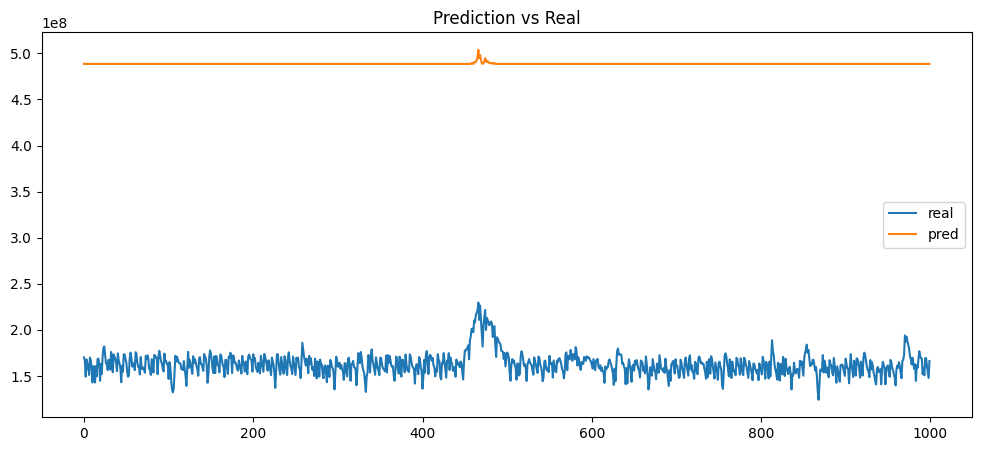

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:1000], label="real")
plt.plot(pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real")
plt.show()

In [86]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(20))

expected_base_fee_next    2187
minute_sin                1072
minute_cos                 988
hour                       982
eth_volatility_1h          861
base_fee_lag_300           736
last_eth_price             726
base_fee_per_gas           472
eth_return_1h              471
utilization_ma_20          456
utilization_ma_50          431
utilization_ma_5           380
height                     367
hour_cos                   345
base_fee_lag_100           276
hour_sin                   209
gas_limit                  202
base_fee_vol_20            189
base_fee_vol_300           182
eth_return_10m             174
dtype: int32


In [87]:
baseline_pred = X_test["base_fee_lag_1"]

mae_baseline = mean_absolute_error(y_test, baseline_pred)

print("Baseline MAE:", mae_baseline)
print("Model MAE:", mae)

Baseline MAE: 11099575.663593117
Model MAE: 417921629.0773042


In [88]:
417921629.0773042 / 10**9

0.4179216290773042

In [89]:
11099575 / 10**9

0.011099575

### Модель для прогнозирования газа через день

In [101]:
target = "target_1d"

X_train = train.drop(columns=targets)
y_train = train[target]

X_val = val.drop(columns=targets)
y_val = val[target]

X_test = test.drop(columns=targets)
y_test = test[target]

In [102]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=30,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций (можно убрать)
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11640
[LightGBM] [Info] Number of data points in the train set: 2019884, number of used features: 52
[LightGBM] [Info] Start training from score 2462978512.062000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1.46151e+10	valid_0's l2: 2.136e+20
Early stopping, best iteration is:
[1]	valid_0's rmse: 2.62049e+09	valid_0's l2: 6.86698e+18


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,30
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2505205551.4637938
RMSE: 2709415938.1473794


In [109]:
2505205551.4637938 / 10**9

2.505205551463794

In [104]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [105]:
def evaluate(y_true, y_pred, name="set"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name} results:")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")

    return mae, rmse

In [106]:
train_mae, train_rmse = evaluate(y_train, train_pred, "TRAIN")
test_mae, test_rmse = evaluate(y_test, test_pred, "TEST")


TRAIN results:
MAE : 2,706,528,566.88
RMSE: 7,910,979,539.60

TEST results:
MAE : 2,505,205,551.46
RMSE: 2,709,415,938.15


In [107]:
overfit_ratio = test_mae / train_mae

print("\nOverfit ratio (test/train):", overfit_ratio)


Overfit ratio (test/train): 0.9256157803484445


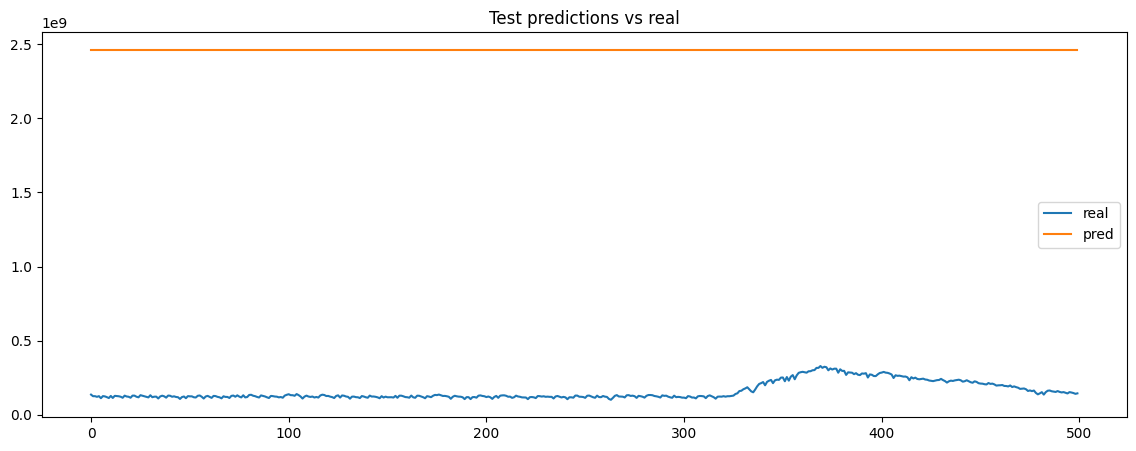

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(y_test.values[:500], label="real")
plt.plot(test_pred[:500], label="pred")

plt.title("Test predictions vs real")
plt.legend()
plt.show()